# Project - 1 (Tableau Dashboard)

## i. Introduction



#### Nama   : Hafizal Shakur


Program ini dibuat dalam rangka menganalisis sebuah data dan membuat hasil analisis tersebut menjadi informasi yang berguna.

## ii. Identify the Problem

Saya adalah seorang yang bekerja pada perusahaan data analisis dan konsultasi. Saat ini, saya perusahaan untuk menyelesaikan masalah dari klien yang bergerak di bidang kesehatan. Klien tersebut berupa sebuah klinik yang cukup besar. Mereka ingin merilis sebuah produk baru berupa jasa pencegahan dan penanggulangan penyakit stroke secara intensif. Layanan intensif tersebut masih dalam proses menentukan program apa saja yang akan diberikan kepada pasien. Karena nantinya program tersebut akan dijalankan dengan kondisi dan kebiasaan berbeda dari tiap pasien. Klien meminta saya untuk menganalisis dari data yang mereka miliki untuk bisa menentukan siapa yang dapat menjadi potensial customer mereka.

Penjelasan Objektif menggunakan SMART framework:

1. Specific: Meningkatkan revenue klinik dari promosi baru yang akan dijalankan.
2. Measurable: Mendapatkan customer yang bersedia mengikuti layanan intensif sebanyak 50 orang.
3. Achieveable: Melakukan promosi melalui media sosial, menawarkan program melalui brosur, melakukan upselling ketika ada pasien yang berkunjung.
4. Relevant: Dengan mendapatkan pasien yang bergabung ke layanan tersebut, akan sebanding dengan revenue yang didapat.
5. Time-Bound: Target harus terpenuhi dalam kurun 1 bulan.

Summary:

Meningkatkan revenue klinik dengan mengaplikasikan program layanan terbaru dengan memiliki target sebanyak 50 orang perbulan dengan cara promosi melalui media sosial, pembagian brosur, dan upselling menawarkan langsung ke potensi customer dan semua dilakukan dalam kurun waktu satu bulan sebelum akhirnya dievaluasi kembali.

Main Problem : 

Meningkatkan nilai revenue dari program baru layanan kesehatan Stroke.

Untuk memudahkan proses analisis, kita harus mengetahui akar permasalahannya, salah satunya dengan cara membuat pertanyaan (5W+1H). Sehingga jawaban dari pertanyaan tersebut akan membantu proses pemecahan masalah. Berikut beberapa pertanyaannya:

1. Berikan data berapa jumlah pasien pria dan wanita yang mengidap hipertensi, penyakit jantung, dan keduanya.
2. Berapa jumlah pasien pria dan wanita yang menderita berat badan tidak normal
3. Berapa jumlah pasien dari tiap kategori smoking_status (ordinal/discrete)
4. Berikan data yang mengelompokkan pasien berdasarkan wilayah tempat tinggal dan status penyakit stroke (pivot)
5. Apakah ada korelasi antara BMI dengan rata-rata gula darah(corr)
6. Apa faktor yang kira-kira mempengaruhi kemunculan penyakit stroke (chi-square)

## iii. Data Loading


Pada bagian Data Loading akan dilakukan proses memuat data dari file csv untuk bisa ditampilkan menjadi sebuah tabel yang kemudian tabel tersebut disimpan di sebuah variabel.

In [7]:
# mengimport library pandas
import pandas as pd

In [9]:
# proses data loading dari file csv
data = pd.read_csv(r'C:\Users\hafiz\OneDrive\Documents\Hacktiv8_Data_Science_Bootcamp\rmt_40\PHASE_0\healthcare-dataset-stroke-data.csv')
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [10]:
# menampilkan informasi data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Setelah melakukan Data Loading, sekarang kita bisa melihat beberapa informasi pada data tersebut.

Tabel yang mencakup keseluruhan data memiliki 5110 rows dan 12 columns yang terdiri atas:
- id: Sebagai unique value
- gender: Jenis kelamin pasien
- age: Usia pasien
- hypertension: Menderita hipertensi (1=ya) (0=tidak)
- hearth_disease: Menderita penyakit jantung (1=ya) (0=tidak)
- ever_married: Status pernikahan
- work_type: Jenis pekerjaan
- Residence_type: Jenis tempat tinggal
- avg_glucose_level: Rata-rata gula darah
- bmi: Index BMI
- smoking_status: Status Perokok
- stroke: Menderita penyakit stroke

Sebetulnya, tiap column pada tabel sudah memiliki data type yang tepat sehingga tidak perlu merubah data typenya lagi. Namun, ada beberapa *missing value* yang harus diatasi agar tidak menggangu validitas data.

In [11]:
# menampilkan nilai unik pada tabel
data.nunique()

id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64

In [12]:
# menampilkan nilai unik pada kolom gender
data['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [13]:
# menampilkan nilai unik pada kolom ever_married
data['ever_married'].unique()

array(['Yes', 'No'], dtype=object)

In [14]:
# menampilkan nilai unik pada kolom work_type
data['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [15]:
# menampilkan nilai unik pada kolom Residence_type
data['Residence_type'].unique()

array(['Urban', 'Rural'], dtype=object)

In [16]:
# menampilkan nilai unik pada kolom smoking_status
data['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

## iv. Data Cleaning

Proses Data Cleaning akan dilakukan hal-hal seperti penggantian nama column, merapikan value pada tiap cell, dan mengatasi *null* value.

In [17]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [18]:
# mengganti nama column
data = data.rename(columns={'id':'ID','gender':'Gender','age':'Age','hypertension':'Hypertension','heart_disease':'Heart Disease',
                            'ever_married':'Married', 'Residence_type':'Residence','avg_glucose_level':'Glucose Level','smoking_status':'Smoking Status',
                            'bmi':'BMI','stroke':'Stroke','work_type':'Work Type'})
data.head()

,ID,Gender,Age,Hypertension,Heart Disease,Married,Work Type,Residence,Glucose Level,BMI,Smoking Status,Stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


Setelah mengganti nama column, proses selanjutnya adalah merapikan value pada tiap cell agar seragam.


In [19]:
# merapikan value
data['Smoking Status'] = data['Smoking Status'].replace({'never smoked' : 'Never', 'smokes': 'Smoking','formerly smoked':'Used to'} )
data['Work Type'] =  data['Work Type'].replace({'Govt_job':'Government','Never_worked':'Unemployed', 'children':'Student'})
data.head()


,ID,Gender,Age,Hypertension,Heart Disease,Married,Work Type,Residence,Glucose Level,BMI,Smoking Status,Stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,Used to,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,Never,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,Never,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,Smoking,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,Never,1


Proses data cleaning selanjutnya adalah menghandle missing value. Dikarenakan jumlah data terbilang cukup banyak dan akan dilakukan proses analisis, maka menghandle missing value bisa dilakukan dengan menghapus data tersebut.

In [20]:
# mengatasi missing value dengan drop
df = data.copy()
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4909 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4909 non-null   int64  
 1   Gender          4909 non-null   object 
 2   Age             4909 non-null   float64
 3   Hypertension    4909 non-null   int64  
 4   Heart Disease   4909 non-null   int64  
 5   Married         4909 non-null   object 
 6   Work Type       4909 non-null   object 
 7   Residence       4909 non-null   object 
 8   Glucose Level   4909 non-null   float64
 9   BMI             4909 non-null   float64
 10  Smoking Status  4909 non-null   object 
 11  Stroke          4909 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 498.6+ KB


Sebelum menghapus missing value, ada baiknya untuk men-copy data asli (data) menjadi variable baru (df) agar data asli tidak hilang. Setelah menghapus beberapa data yang terdapat missing value pada data baru, sekarang jumlahnya berkurang menjadi 4909 rows.

## v. Analysis and Calculation

Bagian Analysis and Calculation berisikan jawaban dari pertanyaan untuk menentukan akar permasalahan. Pertanyaan akan dijawab dengan jawaban yang berbentuk visualisasi data mahupun perhitungan statistika. Sebelum menjawab pertanyaan, kita harus mengimport library terlebih dahulu.

In [21]:
# mengimport library
import matplotlib.pyplot as plt
import seaborn as sns

### 1.  Jumlah pasien pria dan wanita yang mengidap hipertensi, penyakit jantung, dan keduanya.

Untuk menentukan jumlah pasien yang mengidap hipertensi dan/atau penyakit jantung, dilakukan dengan formula query dari pandas.

In [22]:
# menghtung jumlah pasien pengidap Hypertension saja
hypert = df[(df['Hypertension'] == 1) & (df['Heart Disease'] == 0)]
hypert.groupby('Gender')['Hypertension'].count().reset_index()

,Gender,Hypertension
0,Female,227
1,Male,166


Jumlah berikut merupakan pasien pengidap penyakit hipertensi saja.

In [23]:
# menghtung jumlah pasien pengidap Heart Disease saja
heart = df[(df['Heart Disease']== 1) & (df['Hypertension'] == 0)]
heart.groupby('Gender')['Heart Disease'].count().reset_index()

,Gender,Heart Disease
0,Female,76
1,Male,109



Jumlah berikut merupakan pasien pengidap penyakit jantung saja.

In [24]:
# menghitung jumlah pasien pengidap Hypertension dan Heart Disease
hypert_heart = df[(df['Hypertension'] == 1) & (df['Heart Disease'] == 1)]
hypert_heart_grouped = hypert_heart.groupby('Gender')['ID'].count().reset_index()
hypert_heart_grouped.rename(columns={'ID': 'Count'}, inplace=True)
hypert_heart_grouped.set_index('Gender', inplace=True)
hypert_heart_grouped

,Count
Gender,
Female,24
Male,34



Jumlah berikut merupakan pasien pengidap penyakit hipertensi dan jantung.

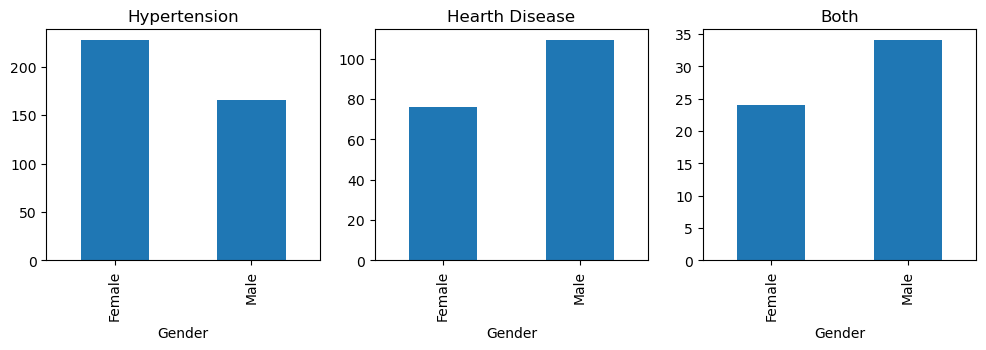

In [25]:
# membuat bar chart sebagai visualisasi data
hypert_bar = hypert.groupby('Gender')['Hypertension'].count()
heart_bar = heart.groupby('Gender')['Heart Disease'].count()
hyphypert_heart_grouped_bar =hypert_heart_grouped

fig, ax = plt.subplots(ncols=3,figsize=(12,3))

hypert_bar.plot(kind='bar', ax=ax[0])
heart_bar.plot(kind='bar', ax=ax[1])
hyphypert_heart_grouped_bar.plot(kind='bar', ax=ax[2])

ax[0].set_title('Hypertension')
ax[1].set_title('Hearth Disease')
ax[2].set_title('Both')

ax[0].legend().set_visible(False)
ax[1].legend().set_visible(False)
ax[2].legend().set_visible(False)

plt.show()

Berikut adalah hasil dari query yang divisualisasikan menggunakan bar chart. Dengan menggunakan bar chart, orang lain akan lebih mudah membaca perbandingan jumlah orang yang menderita hipertensi, penyakit jantung, dan keduanya.

### 2. Pasien pria dan wanita yang menderita berat badan tidak normal

Berat badan tidak normal atau tidak ideal merupakan massa tubuh yang memiliki nilai BMI melebihi atau tidak mencukupi nilai normal. Menurut sumber [source](https://empoweryourknowledgeandhappytrivia.wordpress.com/2015/03/06/body-mass-index-bmi-chart/), index BMI normal terdapat pada angka 18 - 24 melalui perhitungan dari perbandingan tinggi dan berat badan. Untuk memudahkan pekerjaan, akan dibuat sebuah kolom baru untuk memuat BMI kategori yang akan mewakilkan nilai-nilai pada kolom BMI.

In [26]:
# membuat column BMI Category
x = []

for i in df['BMI']:
    if i < 19:
        x.append('Underweight')
    elif 19 <= i < 25:
        x.append('Healthy')
    elif 25 <= i < 30:
        x.append('Overweight')
    elif 30<= i < 40:
        x.append('Obese')
    else:
        x.append('Extremely Obese')

df['BMI Category'] = x
df.head()

,ID,Gender,Age,Hypertension,Heart Disease,Married,Work Type,Residence,Glucose Level,BMI,Smoking Status,Stroke,BMI Category
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,Used to,1,Obese
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,Never,1,Obese
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,Smoking,1,Obese
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,Never,1,Healthy
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,Used to,1,Overweight


Kolom BMI Category telah ditambahkan dan setiap valuenya mewakili nilai BMI.

In [27]:
# menghitung jumlah pasien pria dan wanita berdasarkan BMI Category
bmi_count = df.groupby(['Gender','BMI Category'])['ID'].count().reset_index()
bmi_count.rename(columns={'ID':'Count'}, inplace=True)
bmi_count


,Gender,BMI Category,Count
0,Female,Extremely Obese,288
1,Female,Healthy,782
2,Female,Obese,827
3,Female,Overweight,793
4,Female,Underweight,207
5,Male,Extremely Obese,126
6,Male,Healthy,393
7,Male,Obese,679
8,Male,Overweight,616
9,Male,Underweight,197


Text(0.5, 1.0, 'BMI')

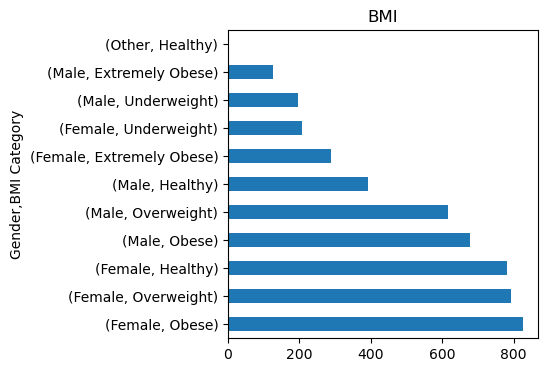

In [28]:
# membuat bar chart BMI Category dan Gender
bmi_bar = df.groupby(['Gender', 'BMI Category'])['ID'].count().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(4,4))
bmi_bar.plot(kind = 'barh', ax=ax).set_title('BMI')

Gambar di atas merupakan visualisasi dari data perbandingan BMI category berdasarkan Gender. Selanjutnya akan dijelaskan cara penulisan lainnya.

In [29]:
# penulisan lain dalam mengelompokkan BMI Category dan Gender
bmi_bar2 = pd.crosstab(df['BMI Category'], df['Gender'])
bmi_bar2

Gender,Female,Male,Other
BMI Category,,,
Extremely Obese,288,126,0
Healthy,782,393,1
Obese,827,679,0
Overweight,793,616,0
Underweight,207,197,0


<Axes: ylabel='BMI Category'>

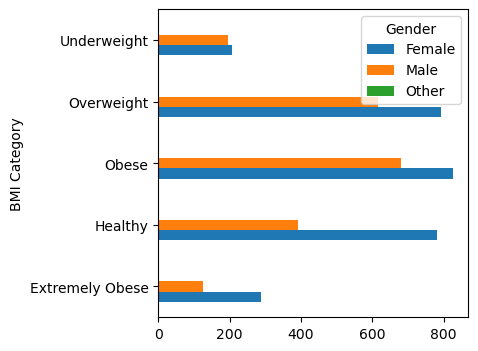

In [30]:
# membuat bar chart
fig, ax = plt.subplots(figsize=(4,4))
bmi_bar2.plot(kind='barh', ax=ax)

Selanjutnya menghitung jumlah data selain Healthy.

In [31]:
unhealthy = df[df['BMI Category'].isin(['Underweight','Overweight','Extremely Obese','Obese'])]
unhealthy_count = unhealthy.groupby('BMI Category')['ID'].count().reset_index()
total_unhealthy = unhealthy_count['ID'].sum()
print(f'Jadi jumlah orang yang memiliki kelainan berat badan adalah: {total_unhealthy} dari total {df['ID'].count()} orang')

Jadi jumlah orang yang memiliki kelainan berat badan adalah: 3733 dari total 4909 orang


Lebih dari 50% populasi data, mengalami kelainan berat badan seperti Underweight, Overweight, Obese, dan Extremely Obese.

### 3. Jumlah pasien dari tiap kategori Smoking Status

Kategori Smoking status dibagi menjadi 4 kategori yaitu Smoking, Used to, Never, dan Unknown. Data Unknown sendiri berasal dari pasien yang tidak mau memberikan pernyataan dari survey tersebut.

In [32]:
# menghitung jumlah pasien berdasarkan Smoking Status
smoke_stat = df[df['Smoking Status'].isin(['Unknown','Used to','Never','Smoking'])]
smoke_size = smoke_stat.groupby('Smoking Status').size().reset_index(name='Count')
smoke_size.set_index('Smoking Status', inplace=True)
smoke_size

,Count
Smoking Status,
Never,1852
Smoking,737
Unknown,1483
Used to,837


Berikut adalah hasil jumlah pasien berdasarkan Smoking Status.

In [33]:
# menghitung jumlah smoking status pada male
smoke_male_counts= pd.crosstab(df[df['Gender']=='Male']['Smoking Status'], columns='Count')
smoke_male_counts

col_0,Count
Smoking Status,
Never,649
Smoking,312
Unknown,672
Used to,378


Berikut adalah hasil jumlah pasien pria berdasarkan Smoking Status.

In [34]:
# menghitung jumlah smoking status pada female
smoke_female_counts= pd.crosstab(df[df['Gender']=='Female']['Smoking Status'], columns='Count')
smoke_female_counts

col_0,Count
Smoking Status,
Never,1203
Smoking,425
Unknown,811
Used to,458


Berikut adalah hasil jumlah pasien wanita berdasarkan Smoking Status.

Text(0.5, 1.0, 'Smoking Status: Female')

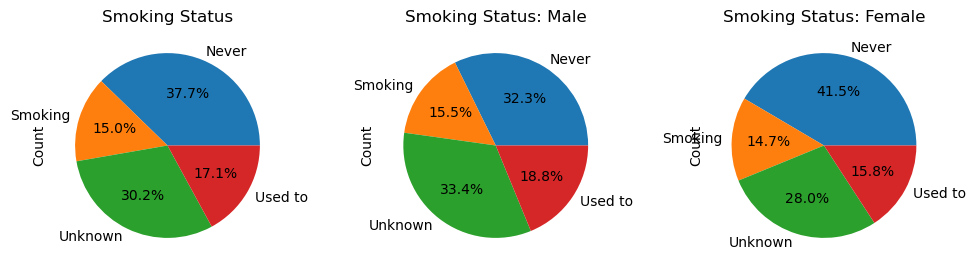

In [35]:
# membuat pie chart untuk Smoking Status

fig, ax = plt.subplots(ncols= 3,figsize=(12,3))
smoke_size.plot(kind = 'pie', y = 'Count',ax=ax[0],autopct='%1.1f%%', legend=False)
ax[0].set_title('Smoking Status')
smoke_male_counts.plot(kind = 'pie',y='Count',ax=ax[1],autopct='%1.1f%%', legend=False)
ax[1].set_title('Smoking Status: Male')
smoke_female_counts.plot(kind = 'pie',y='Count',ax=ax[2],autopct='%1.1f%%', legend=False)
ax[2].set_title('Smoking Status: Female')

Berikut adalah visualisasi data menggunakan pie chart pada kolom smoking status.


### 4. Menghitung jumlah pengidap stroke berdasarkan area tempat tinggal

Menghiutng jumlah pengidap Stroke berdasarkan tempat tinggal digunakan untuk memberikan analisis awal apakah kemunculan penyakit Stroke bisa didasari oleh kepadatan daerah tempat tinggal.

In [36]:
# menghitung jumlah pengidap stroke
df.groupby('Stroke').size()

Stroke
0    4700
1     209
dtype: int64

In [37]:
# membuat pivot table Residence dengan Stroke
pivot = pd.crosstab(df['Residence'], df['Stroke'])
pivot

Stroke,0,1
Residence,,
Rural,2319,100
Urban,2381,109


Di atas merupakan perbandingan antara jumlah pengidap penyakit stroke dengan Residence.

Text(0.5, 1.0, 'Stroke by Residence')

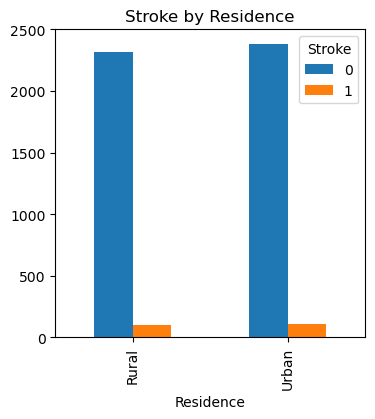

In [38]:
# membuat bar chart dari pivot table
fig, ax = plt.subplots(figsize=(4,4))
pivot.plot(kind='bar', ax=ax).set_title('Stroke by Residence')

Chart perbandingan antara penderita penyakit stroke dengan Residence.

### 5. Mencari hubungan (korelasi) antara index BMI dan Nilai Gula Darah

Untuk mencari tahu apakah terdapat korelasi antara Index BMI dan Gula Darah harus dilakukan pengetesan apakah data tersebut terdistribusi normal atau skew, yang nantinya akan menentukan metode yang digunakan untuk melihat korelasi.

In [39]:
# mengimport library scipy
from scipy import stats

In [40]:
# menentukan distribusi BMI
print(f'Nilai rata-rata: {df['BMI'].mean()}')
print(f'Nilai std deviasi: {df['BMI'].std()}')
skew = df['BMI'].skew()
prompt = 'terdistribusi normal' if -0.5<skew<0.5 else 'terdistribusi skew'
print(f'Nilai distribusi: {skew} {prompt}')

Nilai rata-rata: 28.893236911794663
Nilai std deviasi: 7.854066729680158
Nilai distribusi: 1.0553402052962928 terdistribusi skew


Hasil yang didapat dari perhitungan menunjukkan bahwa data yang dimiliki pada kolom BMI terdistribusi skew (esktrim) dengan nilai: 1.0553402052962928

In [41]:
# menentukan distribusi Glucose Level
print(f'Nilai rata-rata: {df['Glucose Level'].mean()}')
print(f'Nilai std deviasi: {df['Glucose Level'].std()}')
skew = df['Glucose Level'].skew()
prompt = 'terdistribusi normal' if -0.5<skew<0.5 else 'terdistribusi skew'
print(f'Nilai distribusi: {skew} {prompt}')

Nilai rata-rata: 105.3051497249949
Nilai std deviasi: 44.42434066091554
Nilai distribusi: 1.6140261970592311 terdistribusi skew


Hasil yang didapat dari perhitungan menunjukkan bahwa data yang dimiliki pada kolom Glucose Level terdistribusi skew (esktrim) dengan nilai:1.6140261970592311

Dengan pertimbangan kedua data memiliki distribusi skew, bahkan bersifat ekstrim, maka metode korelasi yang akan digunakan adalah metode Spearman. Namun tidak menutup kemungkinan untuk menunjukkan hasil menggunakan kedua metode lainnya (Pearson & Kendall).

In [42]:
# perbandingan menggunakan metode Pearson dan Kendall Tau
corr_r, pval_p = stats.pearsonr(df['BMI'], df['Glucose Level'])
corr_tau, pval_k = stats.kendalltau(df['BMI'], df['Glucose Level'])

print(f"r-correlation: {corr_r:.2f}, p-value: {pval_p}")
print(f"tau-correlation: {corr_tau:.2f}, p-value: {pval_k}")

r-correlation: 0.18, p-value: 2.9762029034340983e-35
tau-correlation: 0.08, p-value: 1.0735689508364345e-15


Hasil di atas merupakan nilai korelasi menggunakan metode pearson dan kendall tau yang menunjukkan bahwa korelasi yang lemah antara bmi dengan kadar gula darah.

In [43]:
# perbandingan menggunakan metode Spearman (valid)
corr_rho, pval_s = stats.spearmanr(df['BMI'], df['Glucose Level'])
print(f"rho-correlation: {corr_rho:.2f}, p-value: {pval_s}")

rho-correlation: 0.11, p-value: 9.160411716327302e-16


Sama seperti perhitungan menggunakan metode Pearson dan Kendall Tau, metode Spearman menghasilkan nilai bmi menunjukkan korelasi arah positif yang lemah dengan kadar rata-rata gula darah. Perhitungan korelasi ini bersifat statistically significant karena nilai p-value < 0.05. Hasil perhitunmgan menggunakan metode Spearman bisa dikatakan hasil yang paling valid karena menyesuaikan kondisi dimana data yang dibabndingkan terdistribusi skew.

### 6. Faktor yang menyebabkan kemunculan penyakit Stroke

Kita bisa menentukan faktor-faktor yang memiliki kecenderungan menjadi penyebab kemunculan penyakit Stroke dengan menggunakan metode chi squared karena perbandingkan yang akan kita buktikan hipotesisnya berbentuk categorical data. Untuk itu, akan dilakukan pengelompokkan data pada glucose menjadi data categorical dan juga menggunakan data pada kolom bmi category. Kadar gula darah dalam tubuh dapat dibagi menjadi beberapa kategori dengan mengacu pada sumber [source](https://www.healthline.com/health/diabetes/high-bg-or-a1c-during-routine-doc-visit#:~:text=Here%E2%80%99s%20how%20the%20results%20are%20interpreted%3A%201%20Normal%3A,126%20mg%2FdL%20or%20higher%20on%20two%20separate%20tests) [source](https://www.drugs.com/cg/what-to-do-if-your-blood-sugar-is-low.html)

In [44]:
print(f'Nilai Glucose Level min: {df['Glucose Level'].min()}')
print(f'Nilai Glucose Level max: {df['Glucose Level'].max()}')
print(f'Nilai Glucose Level mean: {df['Glucose Level'].mean()}')

Nilai Glucose Level min: 55.12
Nilai Glucose Level max: 271.74
Nilai Glucose Level mean: 105.3051497249949


glucose memiliki nilai minimum sebesar 55.12, nilai maksimum sebesar 271.74, dan nilai rata-rata 105.31.

In [45]:
# membuat column Glucose category

y = []

for i in df['Glucose Level']:
    if i < 70:
        y.append('Low')
    elif 70 <= i <101:
        y.append('Normal')
    elif 101 <= i < 126:
        y.append('Prediabetes')
    else:
        y.append('Diabetes')

df['Glucose Category'] = y
df.head()

,ID,Gender,Age,Hypertension,Heart Disease,Married,Work Type,Residence,Glucose Level,BMI,Smoking Status,Stroke,BMI Category,Glucose Category
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,Used to,1,Obese,Diabetes
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,Never,1,Obese,Prediabetes
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,Smoking,1,Obese,Diabetes
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,Never,1,Healthy,Diabetes
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,Used to,1,Overweight,Diabetes


Sekarang saatnya untuk melakukan uji faktor apa saja yang memengaruhi kemunculan penyakit stroke dengan uji hipotesis. Untuk itu, hipotesis akan dijabarkan sebagai berikut:

- H0 : Variabel tidak berpengaruh pada kemunculan stroke
- H1 : Variabel berpengaruh pada penyakit stroke

Pengujian chi-squared akan dilakukan menggunakan metode yang akan menguji variable stroke dengan variabel tertentu lainnya.

In [46]:
df1 = df.drop(columns=['ID','Gender','Age','Glucose Level','BMI','Stroke']).columns

for col in df1:
    cross = pd.crosstab(df[col], df['Stroke'])
    pval = stats.chi2_contingency(cross).pvalue
    text = "maka abaikan H0" if pval<0.05 else ''
    print(f'Nilai p-value dari {col} dan Stroke : {pval} {text} ')

Nilai p-value dari Hypertension dan Stroke : 6.033751208728256e-23 maka abaikan H0 
Nilai p-value dari Heart Disease dan Stroke : 2.0677783295228626e-21 maka abaikan H0 
Nilai p-value dari Married dan Stroke : 3.1283412849388787e-13 maka abaikan H0 
Nilai p-value dari Work Type dan Stroke : 1.7055668658884947e-08 maka abaikan H0 
Nilai p-value dari Residence dan Stroke : 0.7249227580411615  
Nilai p-value dari Smoking Status dan Stroke : 1.2522021032753853e-07 maka abaikan H0 
Nilai p-value dari BMI Category dan Stroke : 1.0757752640749307e-05 maka abaikan H0 
Nilai p-value dari Glucose Category dan Stroke : 1.874834727424229e-16 maka abaikan H0 


Hasil yang didapatkan dari uji hipotesis kemunculan penyakit stroke dengan variabel lainnya menunjukkan bahwa hanya variabel residence yang menyetujui pernyataan pada H0 dimana variabel tersebut tidak memengaruhi kemunculan penyakit stroke. Variabel lain selain residence, memiliki nilai p-value lebih kecil dari 0.05. Nilai 0.05 didapat dari standard persentase yang umum untuk menentukan critical value. Oleh sebab itu, variabel hipertensi, kelainan jantung, status pernikahan, status merokok, bmi, dan kadar gula memiliki kemungkinan berpengaruh pada kemunculan penyakit stroke.

Selanjutnya akan ditentukan seberapa besar persentase kemunculan stroke pada tiap value.

In [47]:
# perbandingan pada column Hypertension
df.groupby('Hypertension')['Stroke'].mean().reset_index()

,Hypertension,Stroke
0,0,0.033423
1,1,0.133038


Data di atas menunjukkan orang yang memiliki hipertensi memiliki persentase lebih besar dibandingkan dengan yang tidak.

In [48]:
# perbandingan pada column Heart Disease
df.groupby('Heart Disease')['Stroke'].mean().reset_index()

,Heart Disease,Stroke
0,0,0.036219
1,1,0.164609


Data di atas menunjukkan orang yang memiliki kelainan jantung memiliki persentase lebih besar dibandingkan dengan yang tidak.

In [49]:
# perbandingan pada column married
df.groupby('Married')['Stroke'].mean().reset_index()

,Married,Stroke
0,No,0.013490
1,Yes,0.058052


Data di atas menunjukkan orang yang sudah menikah memiliki persentase lebih besar dibandingkan dengan yang belum/tidak.

In [50]:
# perbandingan pada column Work Type
df.groupby('Work Type')['Stroke'].mean().sort_values().reset_index()

,Work Type,Stroke
0,Unemployed,0.000000
1,Student,0.001490
2,Government,0.044444
3,Private,0.045180
4,Self-employed,0.068387


Data menunjukkan persentase kemunculan penyakit stroke dengan pekerjaan.

In [51]:
# perbandingan pada column Smoking Status
df.groupby('Smoking Status')['Stroke'].mean().sort_values().reset_index()

,Smoking Status,Stroke
0,Unknown,0.019555
1,Never,0.045356
2,Smoking,0.052917
3,Used to,0.068100


Data menunjukkan persentase kemunculan penyakit stroke dengan status merokok.

In [52]:
# perbandingan pada column BMI Category
df.groupby('BMI Category')['Stroke'].mean().sort_values().reset_index()

,BMI Category,Stroke
0,Underweight,0.002475
1,Healthy,0.029762
2,Extremely Obese,0.045894
3,Obese,0.052457
4,Overweight,0.053229


Data menunjukkan persentase kemunculan penyakit stroke dengan kategori bmi.

In [53]:
# perbandingan pada column Glucose Category
df.groupby('Glucose Category')['Stroke'].mean().sort_values().reset_index()

,Glucose Category,Stroke
0,Low,0.027100
1,Prediabetes,0.030871
2,Normal,0.031503
3,Diabetes,0.095082


Data menunjukkan persentase kemunculan penyakit stroke dengan kadar gula darah.

### 7. Korelasi Antar Fitur

In [56]:
from phik import phik_matrix

c:\Users\hafiz\anaconda3\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable Glucose Level is large: 3852. Are you sure this is not an interval variable? Analysis for pairs of variables including Glucose Level can be slow.
  warnings.warn(
c:\Users\hafiz\anaconda3\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable ID is large: 4909. Are you sure this is not an interval variable? Analysis for pairs of variables including ID can be slow.
  warnings.warn(


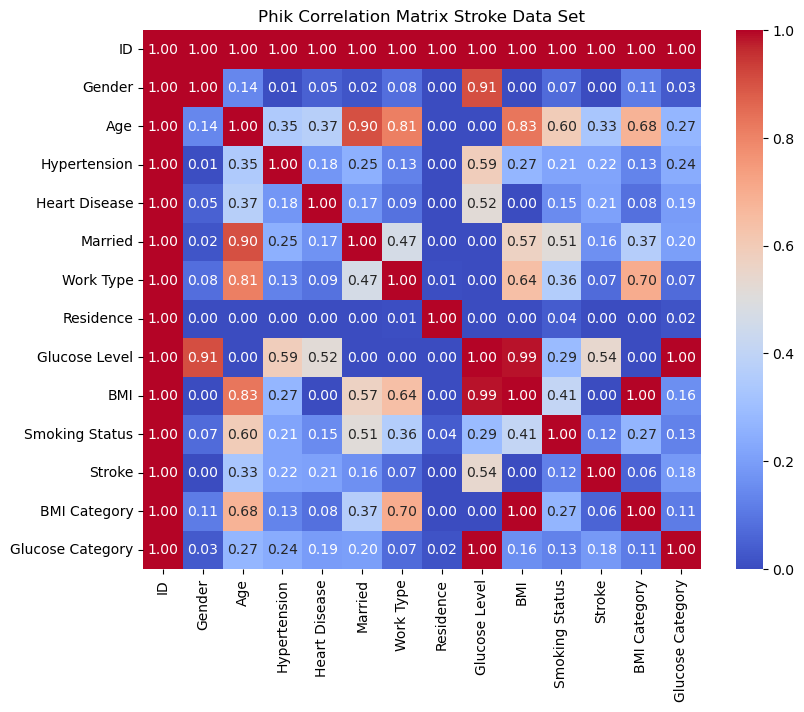

In [58]:
phi_corr = df.phik_matrix(interval_cols=[])

plt.figure(figsize=(9, 7))
sns.heatmap(phi_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Phik Correlation Matrix Stroke Data Set")
plt.show()

## vi. Conclusion

Setelah melakukan analisis pada data yang telah diberikan dari klien, yaitu sebuah klinik kesehatan, adalah daftar pasien yang berkunjung, dengan harapan data tersebut bisa digunakan untuk menentukan fasilitas apa yang akan disediakan klinik dalam melaksanakan program baru pelayanan intensif berupa jasa pencegahan dan pengobatan penyakit stroke, dapat disimpulkan bahwa ada beberapa kondisi dan kebiasaan yang bersangkutan dengan kemunculan penyakit stroke. Namun, saya merasa data yang diolah kurang memenuhi kriteria sampel karena jumlah pengidap stroke pada data terbilang sedikit dibandingkan dengan yang tidak mengalami. Selain itu, ada baiknya untuk melakukan uji secara medis agar lebih terbukti bukan hanya dari analisis data saja.

In [ ]:
# menyimpan file yang sudah bersih ke file csv

df.to_csv('data_stroke_cleaned.csv', index=False)

Data telah disimpan di file csv yang nanti akan digunakan untuk melakukan data visualization dengan Tableu Public.